In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from matplotlib import offsetbox
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.inverse_problems.riemannian_ambient_flow import RiemannianAmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.riemannian_autoencoder.image.pullback.standard import StandardPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
size = 16
results_folder = os.path.join("results",f"mnist_{size}x{size}","tanh")
train_model = False

### Generate data ###

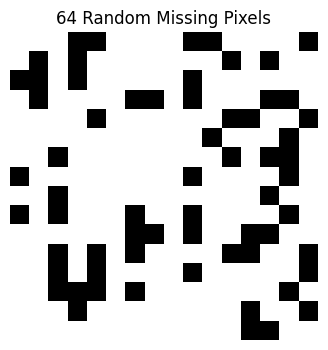

In [2]:
def create_exact_missing_mask(H, W, M):
    # Initialize all present (0s)
    mask = torch.ones(H * W, dtype=torch.bool)
    
    # Generate unique random indices
    indices = torch.randperm(H * W)[:M]
    
    # Set missing pixels
    mask[indices] = False
    
    return mask.view(H, W)

# Create mask
H, W = size, size
cor_level = 0.25
M = int(cor_level * H * W)

mask = create_exact_missing_mask(H, W, M)

plt.figure(figsize=(4,4))
plt.imshow(mask.cpu(), cmap='gray', interpolation='nearest')
plt.title(f'{M} Random Missing Pixels')
plt.axis('off')
plt.show()

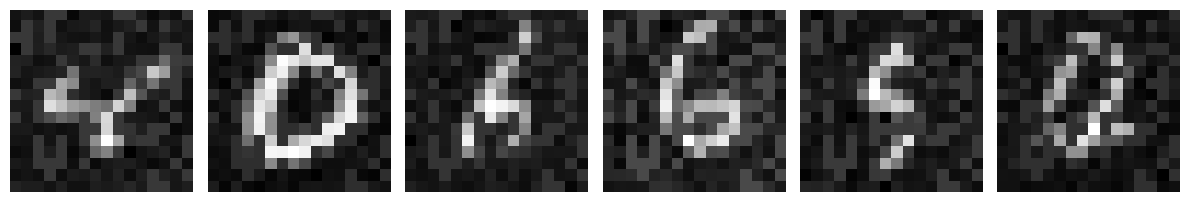

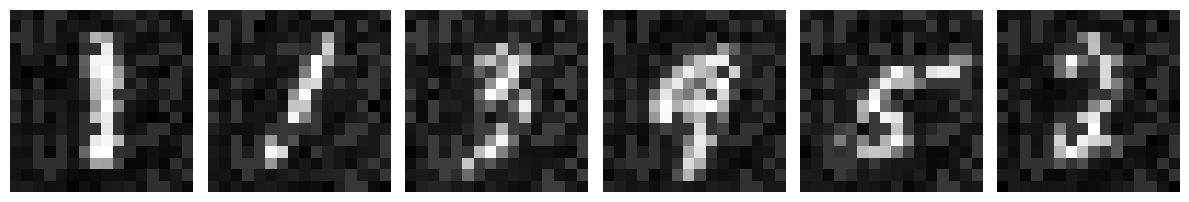

In [25]:
# Construct dataset
mnist_mean = 0.1307
mnist_var = 0.3081

# Define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# Load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train and validation subsets
data_train_clean, data_val_clean = random_split(full_dataset, [train_size, val_size])

# add noise
noise_level = 0.1
data_clean = [(img.clone(), label) for img, label in data_train_clean]
data_train = [((img.clone() + noise_level * torch.randn_like(img)) * mask, label) for img, label in data_train_clean]         
data_val = [((img.clone() + noise_level * torch.randn_like(img)) * mask, label) for img, label in data_val_clean]

# Create the DataLoaders
batch_size = 64
clean_loader = DataLoader(data_clean, batch_size=batch_size, shuffle=False)
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(data_val, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
clean_examples = next(iter(clean_loader))
clean_images, _ = clean_examples
train_examples = next(iter(train_loader))
train_images, _ = train_examples
val_examples = next(iter(val_loader))
val_images, val_labels = val_examples

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Learning Geometry ###

In [4]:
class MaskedForward(nn.Module):
    def __init__(self, mask, pseudo_inverse_reg=None):
        super().__init__()
        self.mask = mask
        self.lambd = pseudo_inverse_reg
    
    def forward(self, x):
        return self.mask.to(x.device) * x
    
    def pseudo_inverse(self, y):
        if self.lambd is not None:
            return 1 / (1 + self.lambd) * self.mask.to(y.device) * y
        else:
            return self.mask.to(y.device) * y

In [ ]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        
        self.maxpool = nn.MaxPool2d(2)
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        d2 = self.down2(self.maxpool(d1))
        d3 = self.down3(self.maxpool(d2))
        
        # Decoder
        u1 = self.up1(d3)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.conv1(u1)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.conv2(u2)
        
        return self.final(u2)


In [6]:
# Define the normalizing flow model
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowImageDiffeomorphism(1, H, W, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [7]:
# Define the conditional normalizing flow model
def create_conditional_distribution_model(in_channels, height, width):
    context_encoder = UNet(2*in_channels, 2*in_channels)
    return distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)

In [8]:
# Initialize the model
forward = MaskedForward(mask)

L = 64
K = 5
order = 6
n_flows = 6
prior_nflow_diffeo = create_flow_model(1, H, W, K, L, order, n_flows)

posterior_dist = create_conditional_distribution_model(1, H, W)

low_rank_reg_param = 0.1
clean_data_reg_param = 1.
model = RiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level, low_rank_reg_param=low_rank_reg_param, clean_data_reg_param=clean_data_reg_param).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-2)

In [9]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, save_dir='results', start_epoch=0):
    best_loss = float('inf')
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        for y, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            optimizer.zero_grad()
            
            y = y.to(device)
            x = clean_images.to(device)
            # Compute loss
            loss = model.reconstruction_loss(y, x=x)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 5 == 0:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [10]:
# Train the model
n_epochs = 100
checkpoint_dir = os.path.join(results_folder, f"checkpoints_latent_dim={L}_kernel_size={K}_order={order}_n_flows={n_flows}")

# Train or load model
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, 'epoch_*_model.pth')), default=None, key=os.path.getctime)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(model, train_loader, optimizer, n_epochs, save_dir=checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

/tmp/ipykernel_81749/2097982646.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path)


RiemannianAmbientFlowProblem(
  (forward_operator): MaskedForward()
  (phi_prior): NFlowImageDiffeomorphism(
    (nflow): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): ActNorm()
          (1-2): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
          )
          (3): MultiLayerTanhParityConv2DTransform(
            (cnn): Sequential(
              (0): MaskedConv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (1): TanhActivation()
              (2): MaskedConv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (3): TanhActivation()
              (4): MaskedConv2d(64, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            )
          )
          (4): ActNorm()
          (5-6): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)

### Evaluating Geometry ###

In [18]:
# Construct reference manifold
euclidean = StandardImageEuclidean(1, H, W)

# Construct pullback manifold
manifold = StandardPullbackImageEuclidean(model.phi_prior)

In [23]:
# Compute reconstructions of the training data points
rec_val_images = model.reconstruct(val_images.to(device)).detach().cpu()


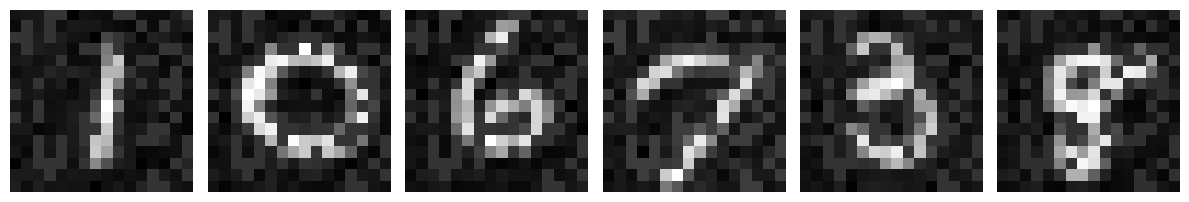

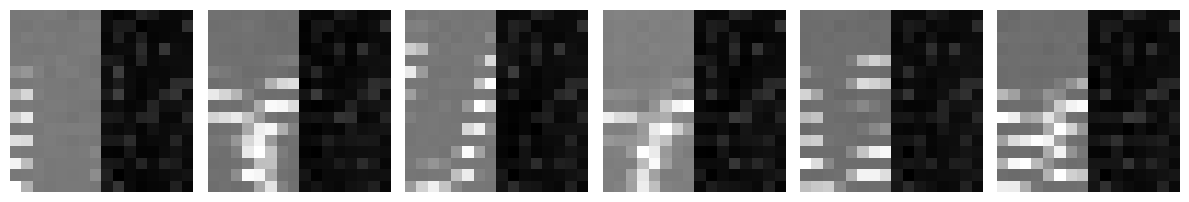

In [24]:
# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(rec_val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Compute geodesics
# Define the dimensions
num_points = num_geodesics = 16

ref_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)
phi_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)

# Create x0 and x1 tensors
x0 = rec_data_train[0:2*num_geodesics:2].to(device)
x1 = rec_data_train[1:2*num_geodesics+1:2].to(device)

# Create a grid of points
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesics
for i in range(num_geodesics):
    ref_geodesics[i] = euclidean.geodesic(x0[i], x1[i], t).detach().cpu()
    phi_geodesics[i] = manifold.geodesic(x0[i], x1[i], t).detach().cpu()

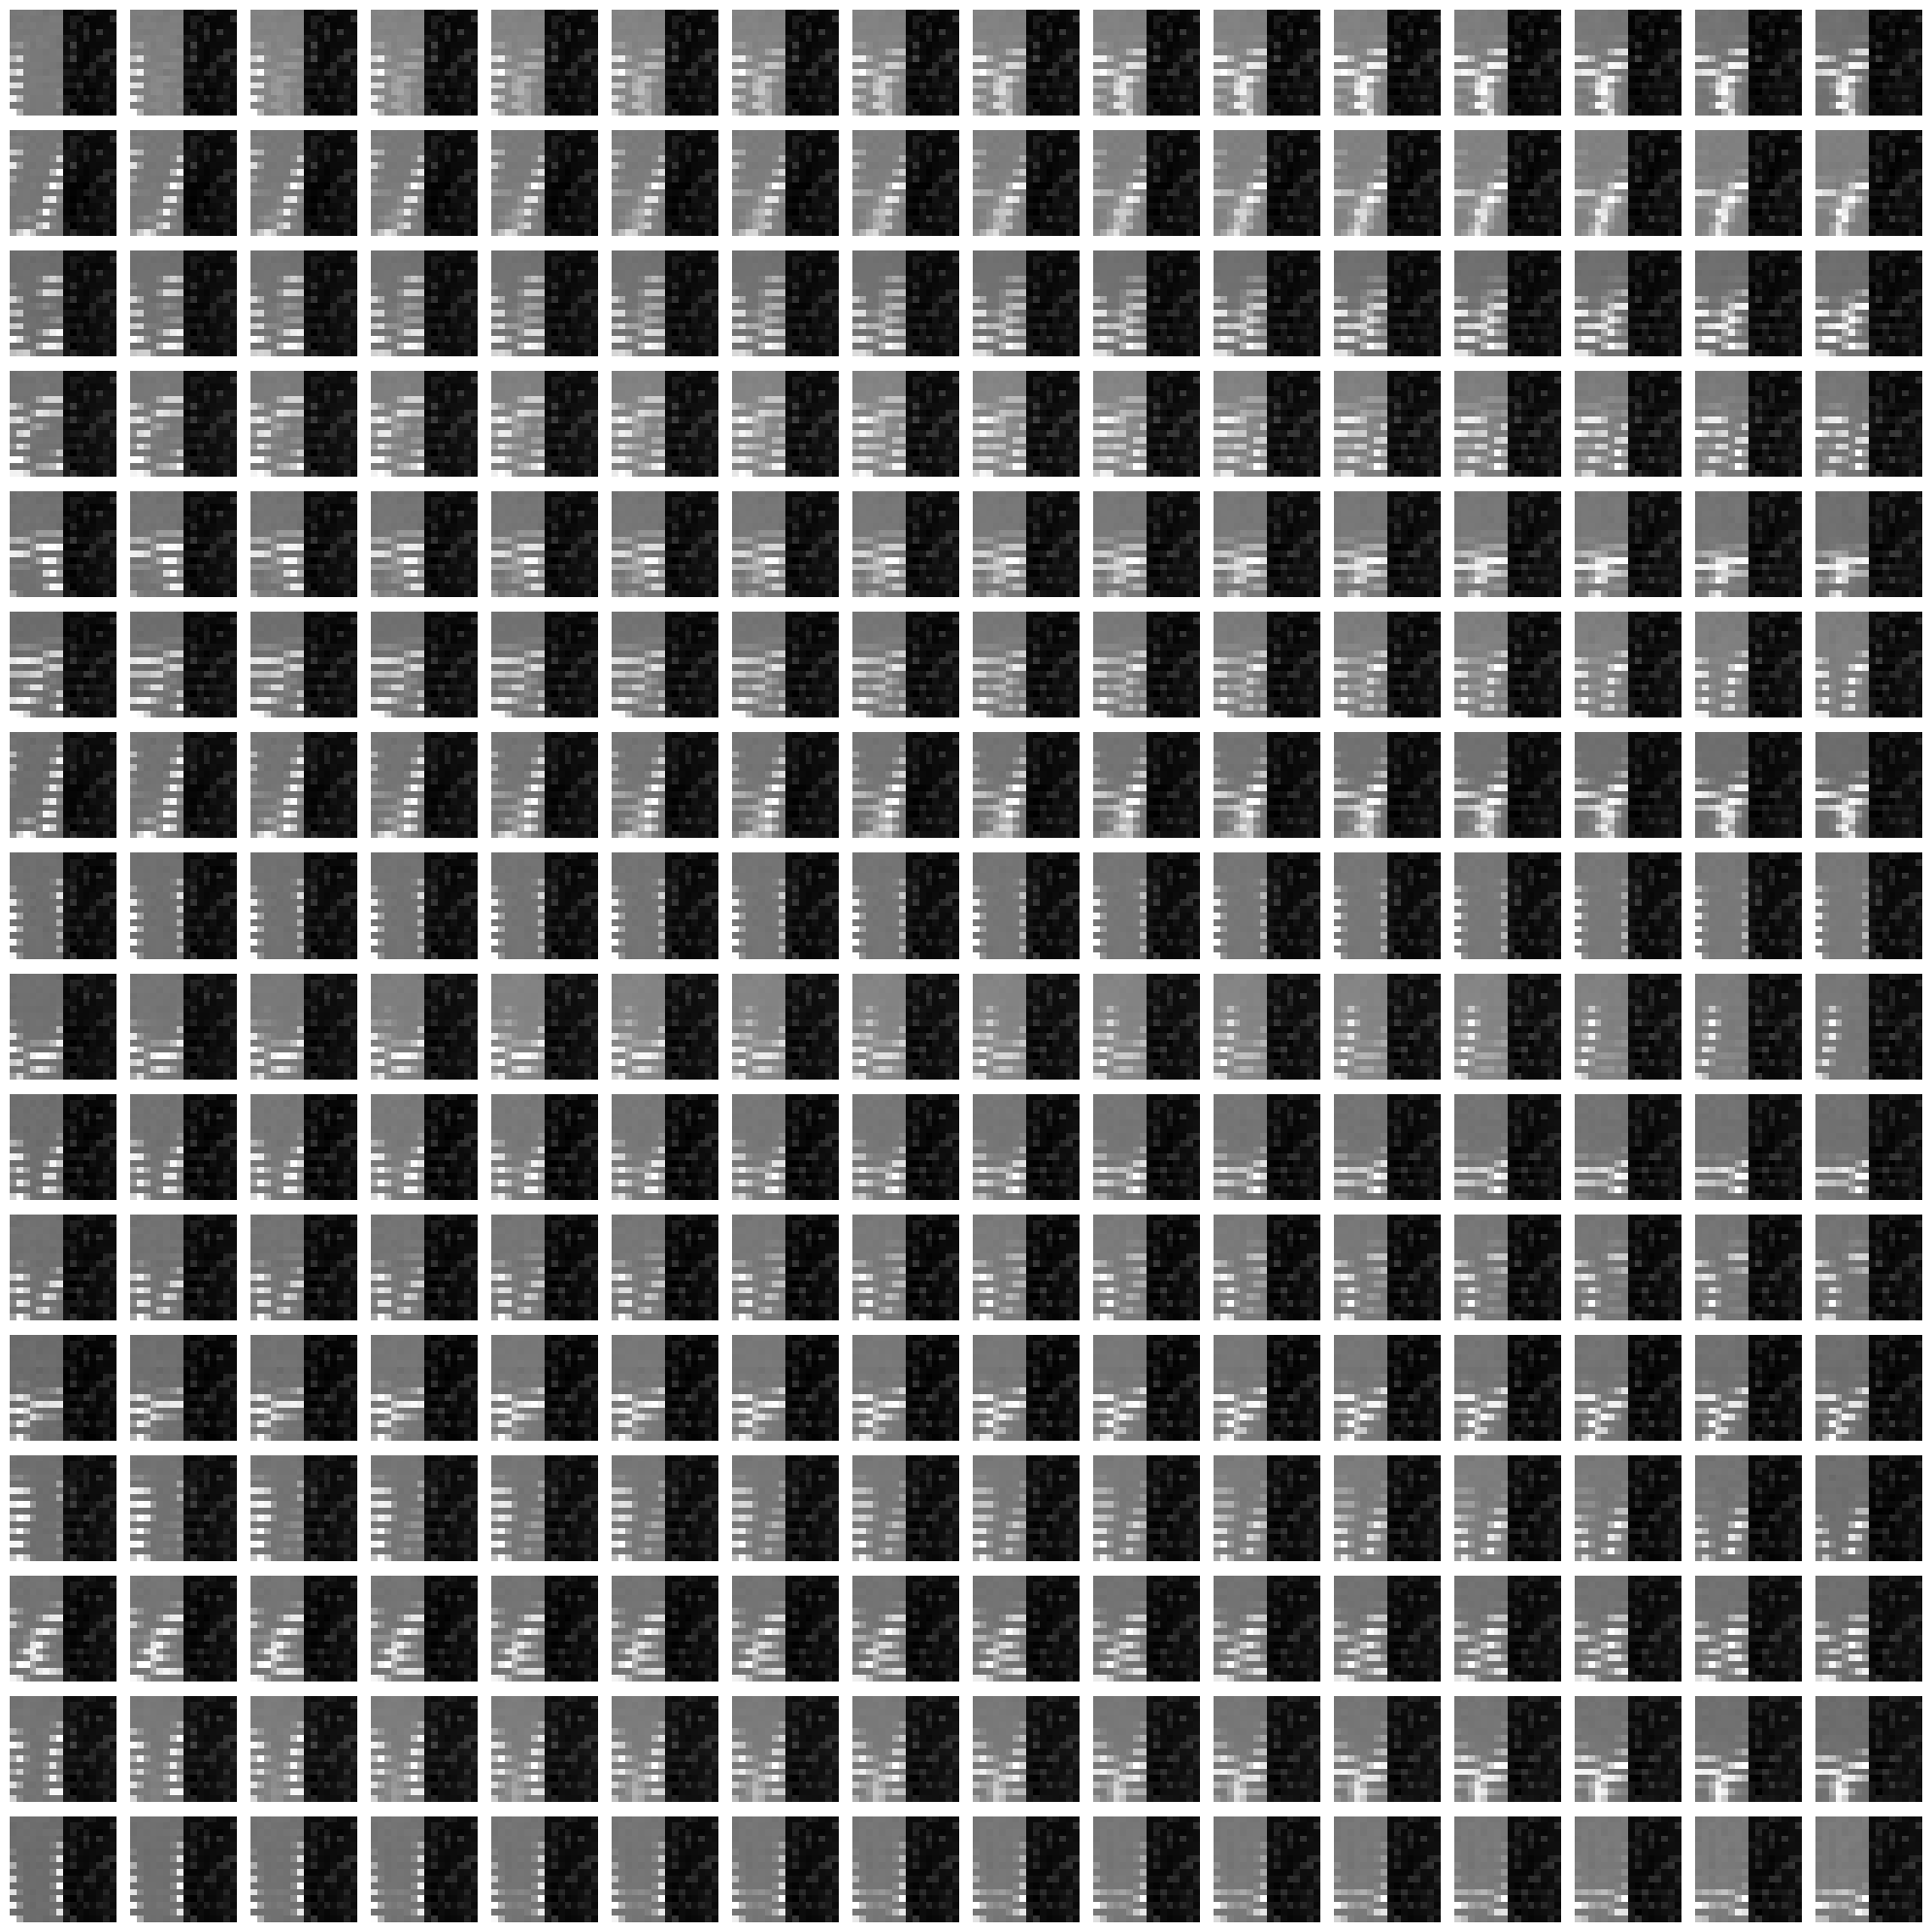

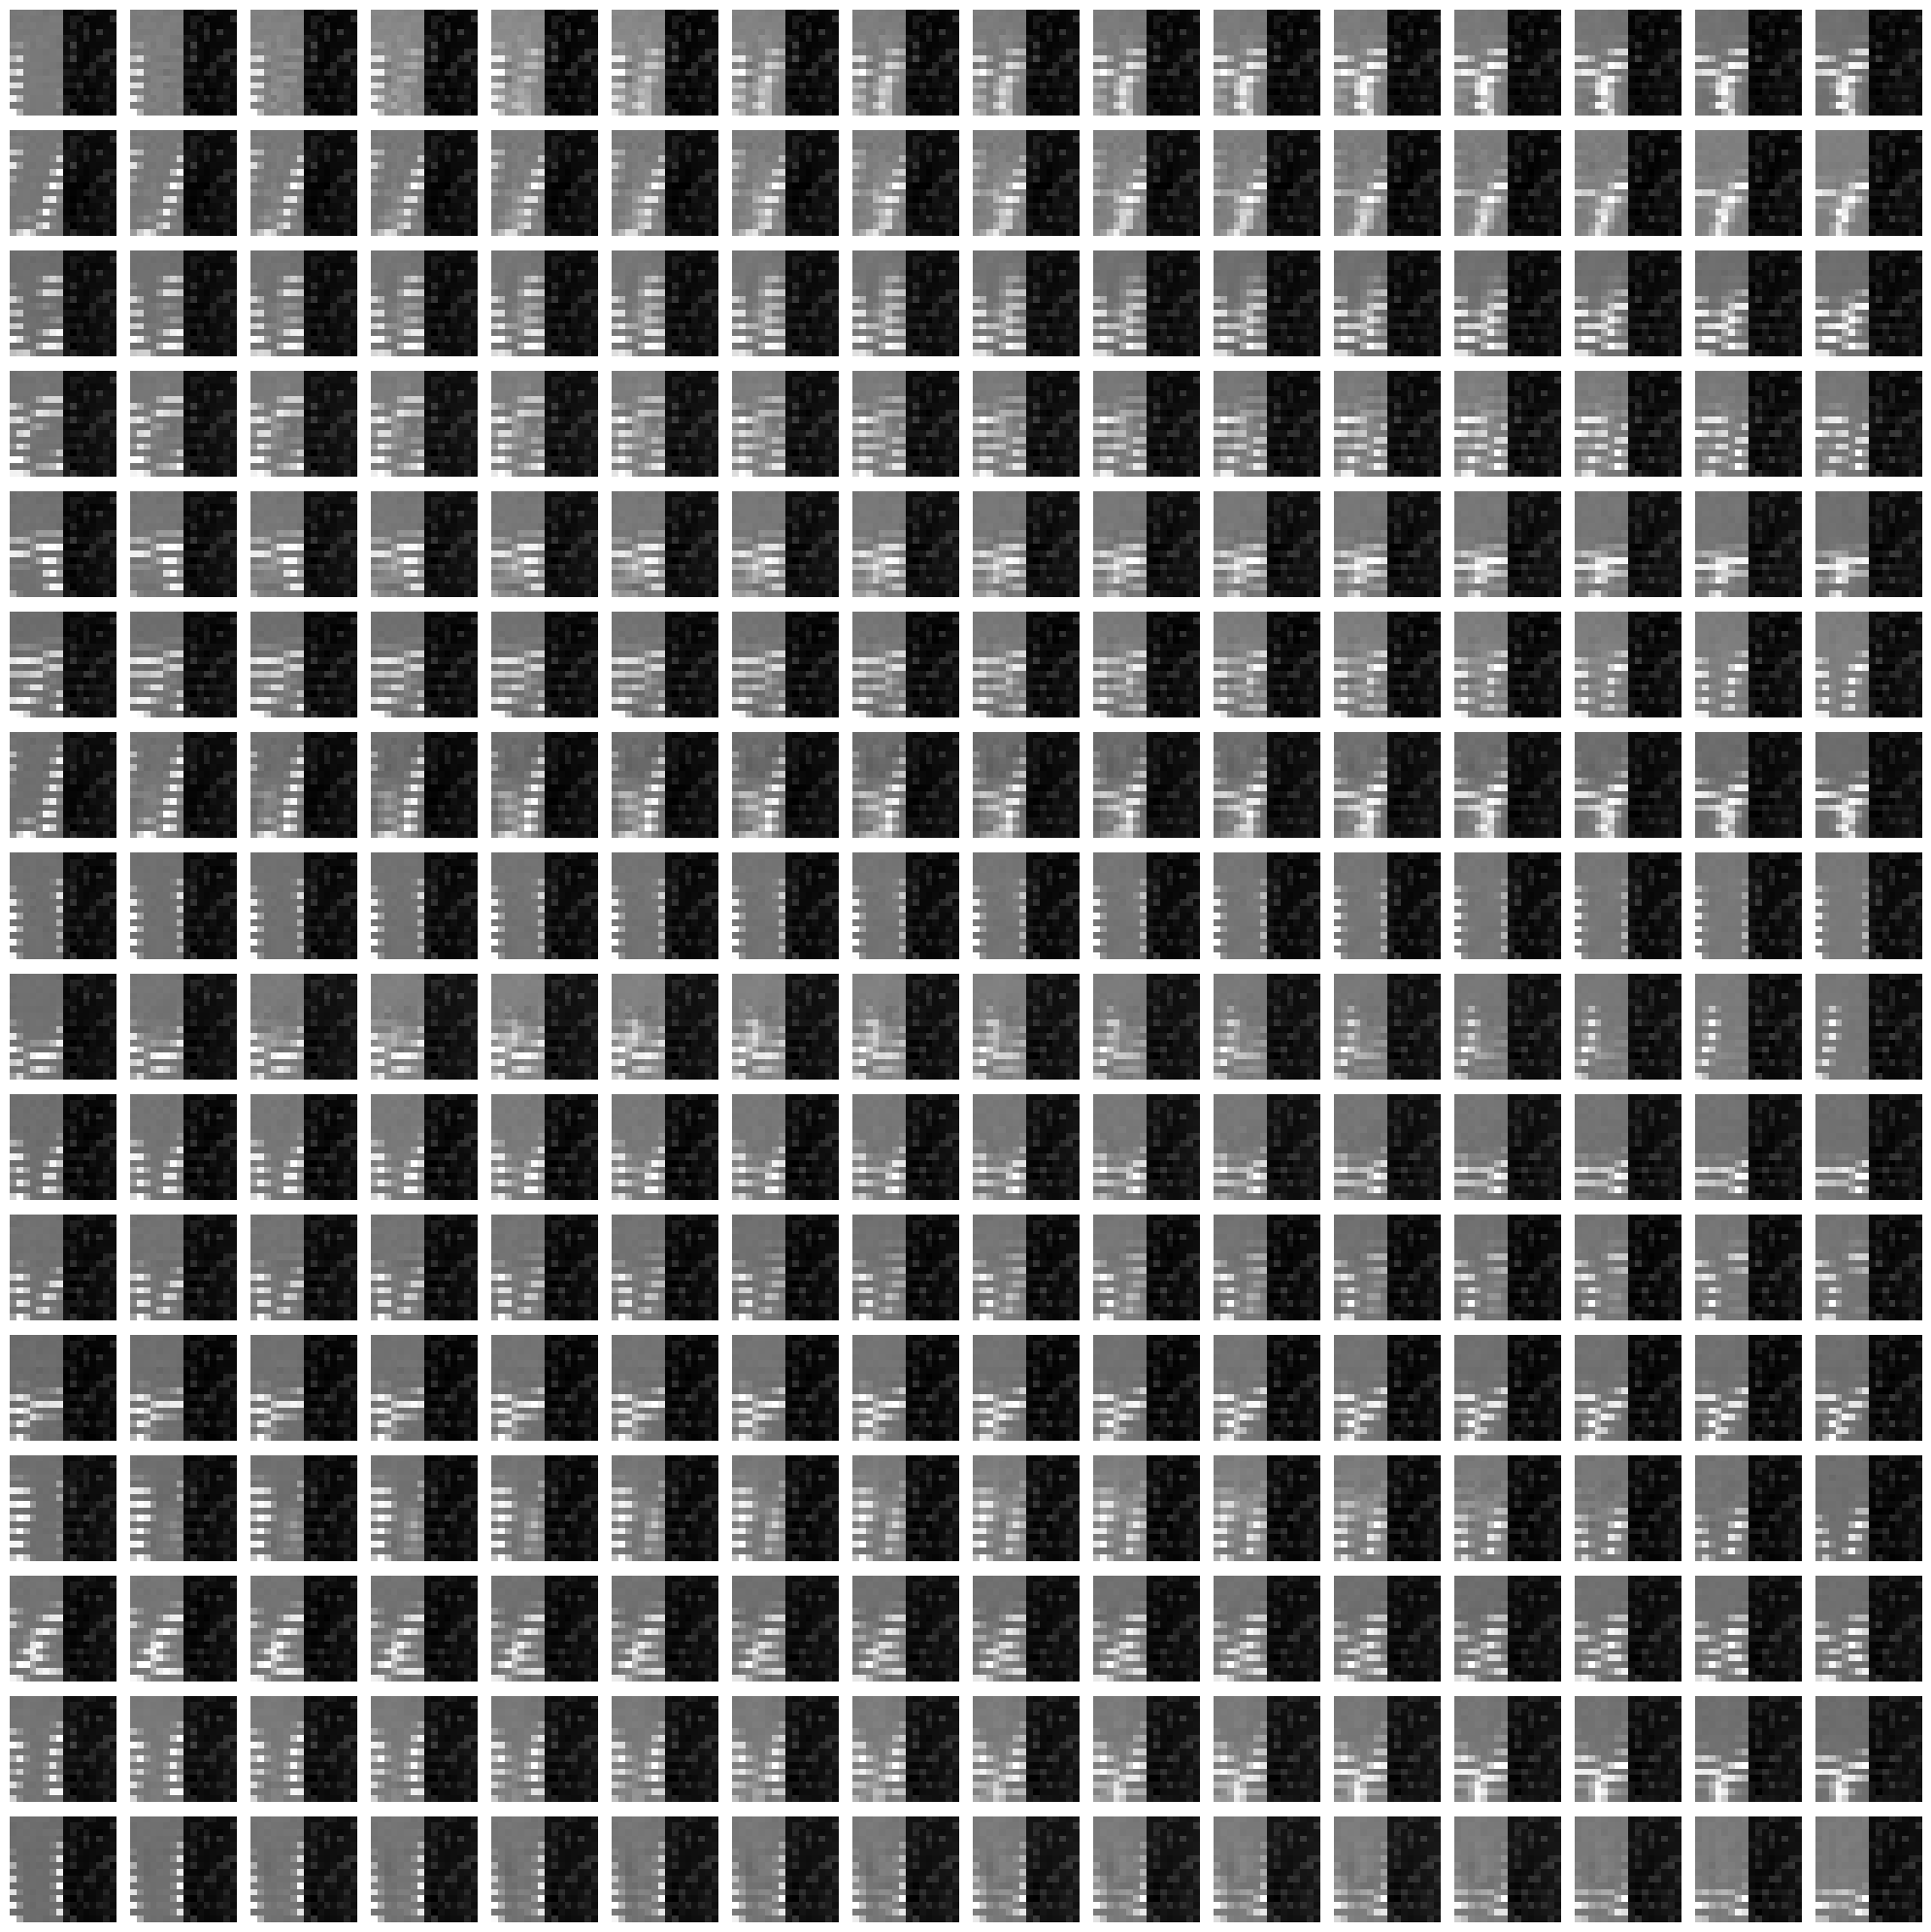

In [22]:
# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(ref_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(phi_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Construct RAE
epsilon = 0.1
rae = StandardPullbackImageRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
d_eps = rae.d_eps

l2_tpca_rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(manifold, rec_data_train[0:100].to(device), d_eps)

constructed a Riemannian autoencoder with d_eps = 1 and effectice eps = 0.04752587154507637
constructed a Riemannian autoencoder with latent dimension = 1 and effectice eps = 0.7939363121986389


### Reconstructing the data ###